# Test function fit_data_with_ref_or_irf

## Example notebook

This notebook shows both supported modes:
- fit using `ref + tau_ref`
- fit using a directly provided `irf`


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from brighteyes_flim import Alignment, mcs


## Load one reference histogram and one data histogram


In [2]:
CHANNEL = 12
C_REF = 1.0
IRF_ITERATIONS = 300
FIT_MODE = "irf_shift"

f_ref = "/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/FLIMLABS_Yellow_slide_2_5ns-17-03-2026-16-18-22.h5"
tau_ref_ns = 2.5
f_data = "/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/01_Convallaria_DFD_40MHz-17-03-2026-16-59-41.h5"

def extract_channel_hist(data_6d, channel=CHANNEL):
    return np.asarray(data_6d[0, 0, :, :, :, channel].sum(axis=(0, 1)), dtype=float)

def build_time_axis(metadata):
    nbin = int(metadata.dfd_nbins)
    period_ns = 1 / (metadata.dfd_freq * 1e6) * 1e9
    dt_ns = period_ns / nbin
    t_ns = np.arange(nbin) * dt_ns
    return nbin, dt_ns, period_ns, t_ns

ref_data_6d, metadata_ref = mcs.load(f_ref)
data_6d, metadata_data = mcs.load(f_data)

ref_hist_raw = extract_channel_hist(ref_data_6d, channel=CHANNEL)
data_hist_raw = extract_channel_hist(data_6d, channel=CHANNEL)

nbin, dt_ns, period_ns, t_ns = build_time_axis(metadata_ref)

ref_hist_raw_norm = ref_hist_raw / ref_hist_raw.sum()
data_hist_raw_norm = data_hist_raw / data_hist_raw.sum()


## Example 1: fit using `ref + tau_ref`

This call estimates the IRF from the reference, fits `dT` and `tau`, returns the IRF shifted by `dT`, and also returns the shifted reference.


Using circular fit with curve_fit_circular
initial_guess [1.0, 0.0, 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}


,irf_source,dT_bins,dT_ns,tau_ns
0,estimated_from_ref,-5.009007,-1.376101,1.434249


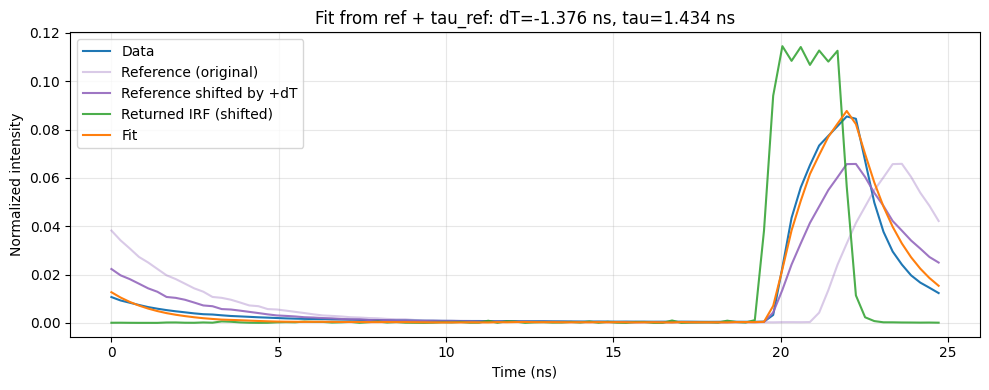

In [3]:
result_from_ref = Alignment.fit_data_with_ref_or_irf(
    t_ns,
    data_hist_raw,
    period_ns,
    ref=ref_hist_raw,
    tau_ref=tau_ref_ns,
    C_ref=C_REF,
    irf_output="shifted",
    shift_output="ref",
    fit_type="circular",
    mode=FIT_MODE,
    irf_iterations=IRF_ITERATIONS,
    regularization=0,
)

display(
    pd.DataFrame(
        [
            {
                "irf_source": result_from_ref["irf_source"],
                "dT_bins": result_from_ref["dT"],
                "dT_ns": result_from_ref["dT_ns"],
                "tau_ns": result_from_ref["tau"],
            }
        ]
    ).round(6)
)

plt.figure(figsize=(10, 4))
plt.plot(t_ns, data_hist_raw_norm, label="Data", color="tab:blue")
plt.plot(t_ns, ref_hist_raw_norm, label="Reference (original)", color="tab:purple", alpha=0.35)
plt.plot(t_ns, result_from_ref["ref_shifted"], label="Reference shifted by +dT", color="tab:purple", alpha=0.9)
plt.plot(t_ns, result_from_ref["irf"], label="Returned IRF (shifted)", color="tab:green", alpha=0.85)
plt.plot(t_ns, result_from_ref["fit"], label="Fit", color="tab:orange")
plt.xlabel("Time (ns)")
plt.ylabel("Normalized intensity")
plt.title(f"Fit from ref + tau_ref: dT={result_from_ref['dT_ns']:.3f} ns, tau={result_from_ref['tau']:.3f} ns")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Example 2: fit using a directly provided `irf`

Here the shifted IRF returned by the previous example is reused as the direct input IRF. The function then returns the data shifted by `-dT`.


Using circular fit with curve_fit_circular
initial_guess [1.0, 0.0, 1.0]
bounds ([0.0, -45.5, 1e-05], [inf, 45.5, np.float64(24.725274725274726)])
circular_params {1: 91.0}


,irf_source,dT_bins,dT_ns,tau_ns
0,provided,-0.000068,-0.000019,1.434377


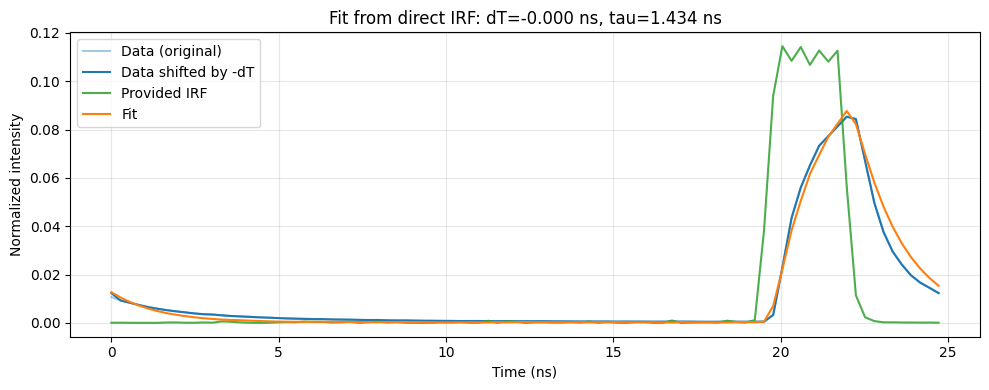

In [4]:
result_from_irf = Alignment.fit_data_with_ref_or_irf(
    t_ns,
    data_hist_raw,
    period_ns,
    irf=result_from_ref["irf"],
    irf_output="original",
    shift_output="data",
    fit_type="circular",
    mode=FIT_MODE,
)

display(
    pd.DataFrame(
        [
            {
                "irf_source": result_from_irf["irf_source"],
                "dT_bins": result_from_irf["dT"],
                "dT_ns": result_from_irf["dT_ns"],
                "tau_ns": result_from_irf["tau"],
            }
        ]
    ).round(6)
)

plt.figure(figsize=(10, 4))
plt.plot(t_ns, data_hist_raw_norm, label="Data (original)", color="tab:blue", alpha=0.4)
plt.plot(t_ns, result_from_irf["data_shifted"], label="Data shifted by -dT", color="tab:blue")
plt.plot(t_ns, result_from_irf["irf"], label="Provided IRF", color="tab:green", alpha=0.85)
plt.plot(t_ns, result_from_irf["fit"], label="Fit", color="tab:orange")
plt.xlabel("Time (ns)")
plt.ylabel("Normalized intensity")
plt.title(f"Fit from direct IRF: dT={result_from_irf['dT_ns']:.3f} ns, tau={result_from_irf['tau']:.3f} ns")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
